In [1]:
import copy
import random
from pathlib import Path

import kagglehub
import pandas as pd
import os
from os import listdir
from os.path import isfile, join

import torch
from torch import nn, optim
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision.transforms import Compose, ToTensor, Normalize, RandomHorizontalFlip, RandomVerticalFlip, \
    RandomRotation

from src.helpers import print_data_folder_structure, plot_img, visual_exploration, plot_training_metrics

random.seed(1)

/Users/vyankov/Documents/DeepLearning/cnn-cifar10-from-scratch/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"Using device: CUDA")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
    print(f"Using device: MPS (Apple Silicon GPU)")
else:
    device = torch.device("cpu")
    print(f"Using device: CPU")

Using device: MPS (Apple Silicon GPU)


In [3]:
dataset_path = kagglehub.competition_download('cifar-10')
labels_path = os.path.join(dataset_path, 'trainLabels.csv')
train_path = os.path.join(dataset_path, 'train')

In [4]:
print_data_folder_structure(dataset_path, 1)

cifar-10/
├── sampleSubmission.csv
├── test.7z
├── train.7z
├── trainLabels.csv
├── test/
└── train/


In [5]:
labels_df = pd.read_csv(labels_path)

In [6]:
files = [(int(Path(join(train_path, f)).stem), f) for f in listdir(train_path) if isfile(join(train_path, f))]

In [7]:
files_df = pd.DataFrame(files, columns=["id", "file_name"])

In [8]:
cifar_pd = pd.merge(labels_df, files_df, on='id', how='inner')

In [9]:
all_labels = cifar_pd['label'].drop_duplicates().reset_index()
all_labels['target'] = all_labels.index
all_labels = all_labels.drop(columns=['index'])

In [10]:
cifar_pd = pd.merge(cifar_pd, all_labels, on='label', how='left')

In [11]:
cifar_pd

,id,label,file_name,target
0,1,frog,1.png,0
1,2,truck,2.png,1
2,3,truck,3.png,1
3,4,deer,4.png,2
4,5,automobile,5.png,3
...,...,...,...,...
49995,49996,bird,49996.png,4
49996,49997,frog,49997.png,0
49997,49998,truck,49998.png,1
49998,49999,automobile,49999.png,3


In [12]:
all_target_labels = [
    'frog',
    'bird',
    'ship',
    'cat'
]
filtered_cifar = cifar_pd[cifar_pd['label'].isin(all_target_labels)]

In [13]:
class TmpCifarDataset(Dataset):
    def __init__(self, train_lib_dir, df, transform=None):
        self.train_lib_dir = train_lib_dir
        self.df = df
        self.transform = transform
        self.labels = df.label

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        item = self.df.iloc[idx]
        image = self.retrieve_image(item)
        if self.transform is not None:
            image = self.transform(image)
        return image, item['target']

    def retrieve_image(self, item):
        image_path = os.path.join(self.train_lib_dir, item['file_name'])
        with Image.open(image_path) as img:
            image = img.convert("RGB")
        return image

    def get_label_description(self, idx):
        return self.df.iloc[idx]['label']

In [14]:
analyze_dataset = TmpCifarDataset(train_path, cifar_pd, transform=ToTensor())
analyze_split = random_split(analyze_dataset, [0.85, 0.15], generator=torch.Generator().manual_seed(1))
analyze_data_loader = DataLoader(analyze_split[0], batch_size=64, shuffle=False)

In [15]:
channel_sum = torch.zeros(3)
channel_squared_sum = torch.zeros(3)
pixel_count = torch.zeros(3)
for images, _ in analyze_data_loader:
    channel_sum += images.sum(dim=(0,2,3))
    channel_squared_sum += (images ** 2).sum(dim=(0, 2, 3))
    pixels_per_channel = images.shape[0] * images.shape[2] * images.shape[3]
    pixel_count += pixels_per_channel
mean = channel_sum / pixel_count
std = (channel_squared_sum / pixel_count - mean ** 2).sqrt()

print("mean:", mean)
print("std: ", std)

mean: tensor([0.4916, 0.4826, 0.4470])
std:  tensor([0.2469, 0.2434, 0.2616])


In [16]:
print(f'Length of the dataset: {len(analyze_dataset)}')

Length of the dataset: 50000


In [17]:
# checking unique classes and amount of samples per class
print(f'Count of unique classes: {len(analyze_dataset.labels.value_counts())}')
analyze_dataset.labels.value_counts().sort_index()

Count of unique classes: 10


label
airplane      5000
automobile    5000
bird          5000
cat           5000
deer          5000
dog           5000
frog          5000
horse         5000
ship          5000
truck         5000
Name: count, dtype: int64

In [18]:
# Checking shapes and channels
for images, labels in analyze_data_loader:
    assert images.ndim == 4
    assert images.shape[1:] == (3, 32, 32)
    assert images.shape[0] == labels.shape[0]

In [19]:
min_pixel = float("inf")
max_pixel = float("-inf")

for images, labels in analyze_data_loader:
    min_pixel = min(min_pixel, images.min().item())
    max_pixel = max(max_pixel, images.max().item())

print(f"Range: {min_pixel} — {max_pixel}")

Range: 0.0 — 1.0


Description: frog
Image shape: torch.Size([3, 32, 32])



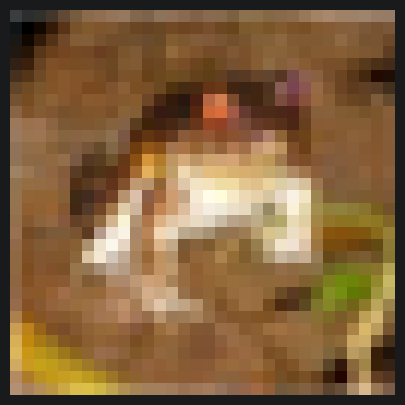

In [20]:
# Look at a sample to check it's working correctly
sel_idx = 0
img, label = analyze_dataset[sel_idx]

# Visualize the image
plot_img(img)

# Print its description
print(f'Description: {analyze_dataset.get_label_description(sel_idx)}')

# Print its shape
print(f'Image shape: {img.shape}\n')  # PIL image shape is (width, height)

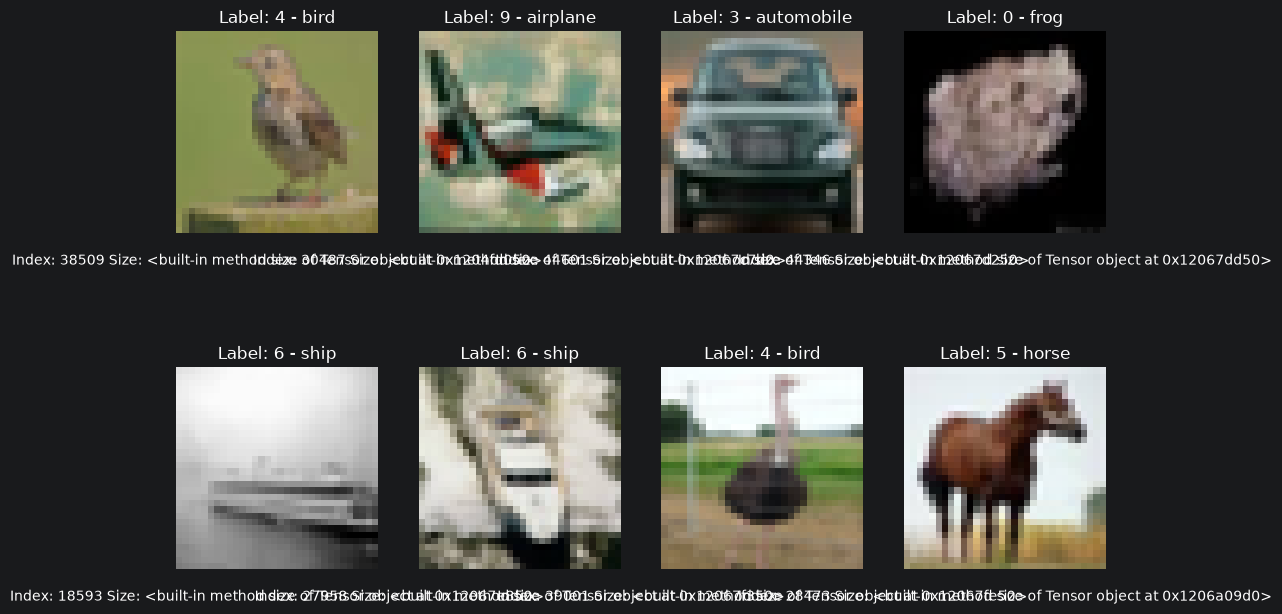

In [21]:
visual_exploration(analyze_dataset, num_rows=2, num_cols=4)

In [22]:
cifarDataset = TmpCifarDataset(train_path, cifar_pd, transform=Compose([ToTensor(), Normalize(mean, std)]))
splits = random_split(cifarDataset, [0.85, 0.15], generator=torch.Generator().manual_seed(1))
train_data_loader = DataLoader(splits[0], batch_size=64, shuffle=True)
val_data_loader = DataLoader(splits[1], batch_size=64, shuffle=False)

In [23]:
def define_transformations(mean, std):
    train_transformations = Compose([
        RandomHorizontalFlip(p=0.5),
        RandomVerticalFlip(p=0.5),
        RandomRotation(15),
        ToTensor(),
        Normalize(mean, std)
    ])

    val_transformations = Compose([
        ToTensor(),
        Normalize(mean, std)
    ])

    return train_transformations, val_transformations

In [24]:
transformations = define_transformations(mean, std)

In [25]:
class CNNBlock(nn.Module):
    def __init__(self, in_channels, out_channels, kernel_size=3, padding=1):
        super(CNNBlock, self).__init__()

        self.block = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size, padding=padding),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(),
            nn.MaxPool2d(2, stride=2)
        )

    def forward(self, x):
        return self.block(x)

In [26]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super(SimpleCNN, self).__init__()

        self.conv_block1 = CNNBlock(3, 32)
        self.conv_block2 = CNNBlock(32, 64)

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(4096, 512),
            nn.ReLU(),
            nn.Dropout(p=0.6),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)

        x = self.classifier(x)

        return x

In [27]:
verify_simple_cnn = SimpleCNN(num_classes=10)
print("Model Structure:\n")
print(verify_simple_cnn)

Model Structure:

SimpleCNN(
  (conv_block1): CNNBlock(
    (block): Sequential(
      (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (conv_block2): CNNBlock(
    (block): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU()
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=4096, out_features=512, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.6, inplace=False)
    (4): Linear(in_features=512, out_features=10, bias=True)
  )
)


In [28]:
# Create a dummy input tensor (batch_size=64, channels=3, height=32, width=32)
dummy_input = torch.randn(64, 3, 32, 32)
print(f"\nInput tensor shape:  {dummy_input.shape}")
# Pass the dummy tensor through the model
output = verify_simple_cnn(dummy_input)
print(f"Output tensor shape: {output.shape}")


Input tensor shape:  torch.Size([64, 3, 32, 32])
Output tensor shape: torch.Size([64, 10])


In [29]:
num_classes = len(analyze_dataset.labels.value_counts())
model = SimpleCNN(num_classes=num_classes)

In [30]:
def train_epoch(model, train_loader, loss_function, optimizer, device):
    model.train()
    running_loss = 0.0
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = loss_function(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

In [31]:
def validate_epoch(model, val_loader, loss_function, device):
    model.eval()
    running_val_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)

            val_loss = loss_function(outputs, labels)
            running_val_loss += val_loss.item()

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_val_loss = running_val_loss / len(val_loader.dataset)
    epoch_accuracy = 100.0 * correct / total

    return epoch_val_loss, epoch_accuracy

In [32]:
def training_loop(model, train_loader, val_loader, loss_function, optimizer, num_epochs, device):
    model.to(device)

    best_val_accuracy = 0.0
    best_model_state = None
    best_epoch = 0

    train_losses, val_losses, val_accuracies = [], [], []

    print("--- Training Started ---")

    for epoch in range(num_epochs):
        epoch_loss = train_epoch(model, train_loader, loss_function, optimizer, device)
        train_losses.append(epoch_loss)

        epoch_val_loss, epoch_accuracy = validate_epoch(model, val_loader, loss_function, device)
        val_losses.append(epoch_val_loss)
        val_accuracies.append(epoch_accuracy)

        print(f"Epoch [{epoch+1}/{num_epochs}], Train Loss: {epoch_loss:.4f}, Val Loss: {epoch_val_loss:.4f}, Val Accuracy: {epoch_accuracy:.2f}%")

        if epoch_accuracy > best_val_accuracy:
            best_val_accuracy = epoch_accuracy
            best_epoch = epoch + 1
            best_model_state = copy.deepcopy(model.state_dict())

    print("--- Finished Training ---")

    if best_model_state:
        print(f"\n--- Returning best model with {best_val_accuracy:.2f}% validation accuracy, achieved at epoch {best_epoch} ---")
        model.load_state_dict(best_model_state)

    metrics = [train_losses, val_losses, val_accuracies]

    return model, metrics

In [33]:
# Loss function
loss_function = nn.CrossEntropyLoss()

# Optimizer for the model with weight_decay
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=0.0005)

--- Training Started ---
Epoch [1/50], Train Loss: 1.4890, Val Loss: 0.0179, Val Accuracy: 58.41%
Epoch [2/50], Train Loss: 1.1831, Val Loss: 0.0159, Val Accuracy: 64.17%
Epoch [3/50], Train Loss: 1.0753, Val Loss: 0.0147, Val Accuracy: 67.05%
Epoch [4/50], Train Loss: 1.0027, Val Loss: 0.0139, Val Accuracy: 68.71%
Epoch [5/50], Train Loss: 0.9632, Val Loss: 0.0139, Val Accuracy: 68.80%
Epoch [6/50], Train Loss: 0.9067, Val Loss: 0.0136, Val Accuracy: 69.77%
Epoch [7/50], Train Loss: 0.8762, Val Loss: 0.0126, Val Accuracy: 72.11%
Epoch [8/50], Train Loss: 0.8357, Val Loss: 0.0125, Val Accuracy: 72.00%
Epoch [9/50], Train Loss: 0.8101, Val Loss: 0.0120, Val Accuracy: 73.64%
Epoch [10/50], Train Loss: 0.7812, Val Loss: 0.0121, Val Accuracy: 73.09%
Epoch [11/50], Train Loss: 0.7483, Val Loss: 0.0120, Val Accuracy: 73.56%
Epoch [12/50], Train Loss: 0.7332, Val Loss: 0.0117, Val Accuracy: 74.17%
Epoch [13/50], Train Loss: 0.7123, Val Loss: 0.0117, Val Accuracy: 73.87%
Epoch [14/50], Train L

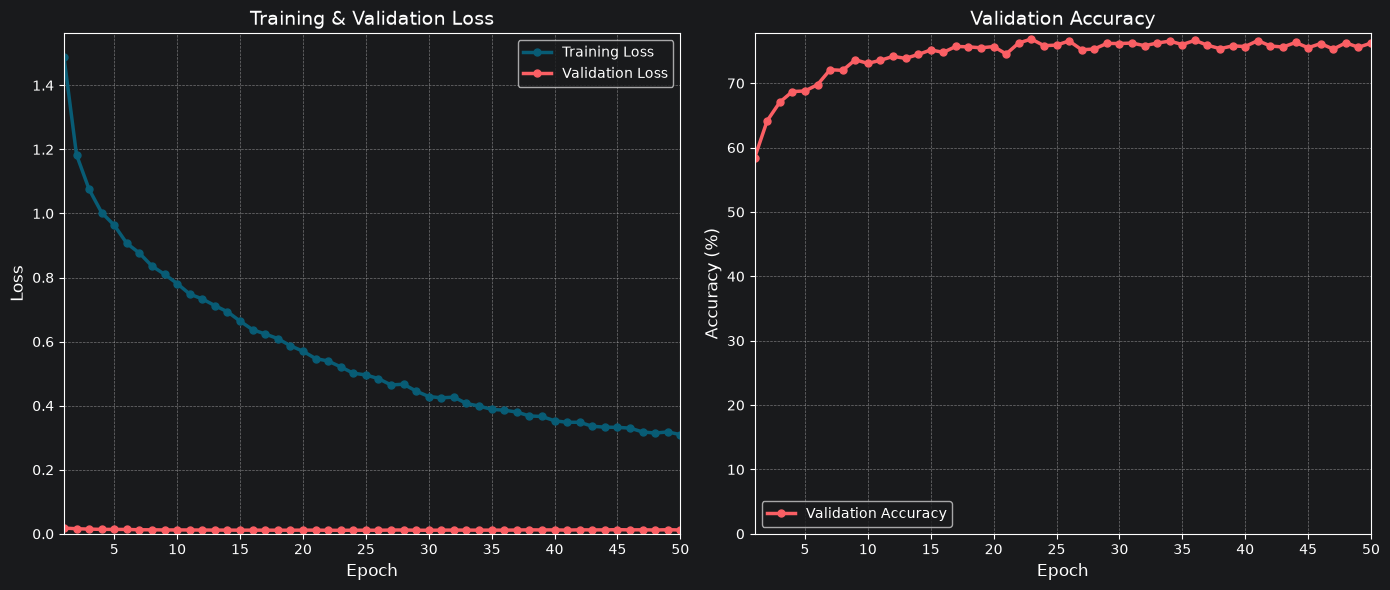

In [34]:
trained_model, training_metrics = training_loop(
    model=model,
    train_loader=train_data_loader,
    val_loader=val_data_loader,
    loss_function=loss_function,
    optimizer=optimizer,
    num_epochs=50,
    device=device
)

print("\n--- Training Plots ---\n")
plot_training_metrics(training_metrics)